# Code Review Agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ai-agent-workshop/code-review-agent/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ai-agent-workshop/code-review-agent/demo.ipynb)

An agent that scans a PR diff for common issues — secrets, bare excepts, leftover debug code, TODOs — and writes a review summary.

**What this notebook covers:**
1. Parsing a unified diff into added lines
2. Rule-based findings (secrets, bare except, print/debugger leftovers, TODOs, long lines)
3. Running it on a sample PR diff
4. Visualizing findings by severity
5. A "Try Your Own" section to review your own diff


## Step 1: Why automate the first pass?

PRs sit unreviewed for days because reviewers are busy and the first pass — catching secrets,
bare excepts, leftover `print()`/`pdb` calls, unresolved TODOs — is mechanical. This agent does
that pass instantly so a human reviewer can focus on logic and design instead of nitpicks.


In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field
from typing import List, Optional


@dataclass
class Finding:
    file: str
    line: int
    severity: str
    message: str


@dataclass
class ReviewResult:
    findings: List[Finding] = field(default_factory=list)
    summary: str = ""
    files_reviewed: int = 0
    lines_added: int = 0


SECRET_PATTERNS = [
    re.compile(r"(?i)(api[_-]?key|secret|password|token)\s*[:=]\s*['\"][A-Za-z0-9_\-]{8,}['\"]"),
    re.compile(r"AKIA[0-9A-Z]{16}"),
]

RULES = [
    ("bare except", re.compile(r"^\s*except\s*:\s*$"), "high", "bare 'except:' swallows all errors, catch specific exceptions"),
    ("print left in", re.compile(r"^\s*print\("), "medium", "leftover print() — use logging instead"),
    ("todo marker", re.compile(r"(?i)#\s*(TODO|FIXME|HACK)"), "medium", "unresolved TODO/FIXME marker"),
    ("debugger left in", re.compile(r"^\s*(import pdb|pdb\.set_trace\(\))"), "critical", "debugger breakpoint left in code"),
]


def _parse_diff(diff_text: str):
    current_file = "unknown"
    current_line = 0
    for raw_line in diff_text.splitlines():
        if raw_line.startswith("+++ "):
            current_file = raw_line[4:].lstrip("b/").strip()
            continue
        if raw_line.startswith("@@"):
            match = re.search(r"\+(\d+)", raw_line)
            current_line = int(match.group(1)) - 1 if match else 0
            continue
        if raw_line.startswith("+") and not raw_line.startswith("+++"):
            current_line += 1
            yield current_file, current_line, raw_line[1:]
        elif not raw_line.startswith("-"):
            current_line += 1


def _rule_based_findings(diff_text: str) -> List[Finding]:
    findings: List[Finding] = []
    for file, line_no, content in _parse_diff(diff_text):
        for pattern in SECRET_PATTERNS:
            if pattern.search(content):
                findings.append(Finding(file, line_no, "critical", "possible hardcoded secret/credential"))
                break
        for _name, pattern, severity, message in RULES:
            if pattern.search(content):
                findings.append(Finding(file, line_no, severity, message))
        if len(content) > 120:
            findings.append(Finding(file, line_no, "low", f"line exceeds 120 chars ({len(content)})"))
    return findings


def _rule_based_summary(findings: List[Finding], files_reviewed: int, lines_added: int) -> str:
    if not findings:
        return f"Reviewed {files_reviewed} file(s), {lines_added} line(s) added. No issues flagged — looks safe to merge."
    counts = {}
    for f in findings:
        counts[f.severity] = counts.get(f.severity, 0) + 1
    parts = ", ".join(f"{n} {sev}" for sev, n in sorted(counts.items(), key=lambda x: ["critical", "high", "medium", "low"].index(x[0])))
    verdict = "blocks merge until fixed" if counts.get("critical") or counts.get("high") else "safe to merge after minor cleanup"
    return f"Reviewed {files_reviewed} file(s), {lines_added} line(s) added. Found {len(findings)} issue(s): {parts}. Verdict: {verdict}."


def review_diff(diff_text: str) -> ReviewResult:
    findings = _rule_based_findings(diff_text)
    files_reviewed = len({f.file for f in findings}) or len(re.findall(r"^\+\+\+ ", diff_text, re.M))
    lines_added = len(re.findall(r"^\+[^+]", diff_text, re.M))
    summary = _rule_based_summary(findings, files_reviewed, lines_added)
    return ReviewResult(findings=findings, summary=summary, files_reviewed=files_reviewed, lines_added=lines_added)

print("Reviewer loaded.")

Reviewer loaded.


## Step 2: Run it on a sample PR diff

A realistic diff with a hardcoded key, a bare except, a leftover print, and a TODO.

In [2]:
sample_diff = """--- a/app/utils.py
+++ b/app/utils.py
@@ -10,6 +10,12 @@
 def process(data):
+    api_key = \"sk-1234567890abcdef\"
+    try:
+        result = call_api(data, api_key)
+    except:
+        print(\"failed\")
+    # TODO: add retry logic
+    return result
"""

result = review_diff(sample_diff)
print(result.summary)
print()
for f in result.findings:
    print(f"[{f.severity.upper():8s}] {f.file}:{f.line}  {f.message}")

Reviewed 1 file(s), 7 line(s) added. Found 4 issue(s): 1 critical, 1 high, 2 medium. Verdict: blocks merge until fixed.

[CRITICAL] app/utils.py:11  possible hardcoded secret/credential
[HIGH    ] app/utils.py:14  bare 'except:' swallows all errors, catch specific exceptions
[MEDIUM  ] app/utils.py:15  leftover print() — use logging instead
[MEDIUM  ] app/utils.py:16  unresolved TODO/FIXME marker


## Step 3: Batch test across several PR diffs

Simulate an open PR queue and see how the agent triages each one.

In [3]:
sample_prs = {
    "PR #101 (auth fix)": sample_diff,
    "PR #102 (clean refactor)": """--- a/app/models.py
+++ b/app/models.py
@@ -1,2 +1,4 @@
 def get_user(id):
+    if id is None:
+        raise ValueError(\"id required\")
     return db.query(id)
""",
    "PR #103 (debug leftover)": """--- a/app/main.py
+++ b/app/main.py
@@ -5,2 +5,4 @@
 def run():
+    import pdb; pdb.set_trace()
     start_server()
""",
}

pr_results = {name: review_diff(diff) for name, diff in sample_prs.items()}
for name, r in pr_results.items():
    verdict = r.summary.split("Verdict:")[-1].strip()
    print(f"{name:28s} | {len(r.findings)} finding(s) | {verdict}")

PR #101 (auth fix)           | 4 finding(s) | blocks merge until fixed.
PR #102 (clean refactor)     | 0 finding(s) | Reviewed 1 file(s), 2 line(s) added. No issues flagged — looks safe to merge.
PR #103 (debug leftover)     | 1 finding(s) | blocks merge until fixed.


## Visualization: findings by severity across the PR queue

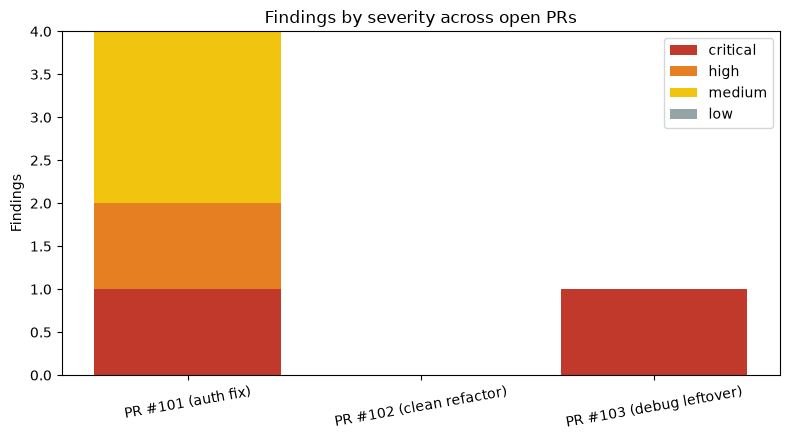

In [4]:
import matplotlib.pyplot as plt

severities = ["critical", "high", "medium", "low"]
colors = {"critical": "#C0392B", "high": "#E67E22", "medium": "#F1C40F", "low": "#95A5A6"}

counts_by_pr = {}
for name, r in pr_results.items():
    counts = {s: 0 for s in severities}
    for f in r.findings:
        counts[f.severity] += 1
    counts_by_pr[name] = counts

fig, ax = plt.subplots(figsize=(8, 4.5))
bottom = [0] * len(counts_by_pr)
names = list(counts_by_pr.keys())
for sev in severities:
    values = [counts_by_pr[n][sev] for n in names]
    ax.bar(names, values, bottom=bottom, label=sev, color=colors[sev])
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_ylabel("Findings")
ax.set_title("Findings by severity across open PRs")
ax.legend()
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("findings_by_severity.png", dpi=150)
plt.show()

## Summary

The agent gives every PR an instant first pass — secrets, bare excepts, debug leftovers, and
TODOs surfaced immediately, with a verdict on whether it blocks merge. Reviewers spend their time
on logic and design instead of catching the mechanical stuff.


## Try Your Own

Uncomment and paste your own diff (or fetch a real PR via `fetch_pr_diff` in `reviewer.py`):

In [5]:
# my_diff = """paste a unified diff here"""
# my_result = review_diff(my_diff)
# print(my_result.summary)
# for f in my_result.findings:
#     print(f.severity, f.file, f.line, f.message)

---
**[← Back to portfolio](../../README.md)**

For the interactive version with a UI and live GitHub PR fetching:
```bash
pip install -r requirements.txt
streamlit run app.py
```
Set `ANTHROPIC_API_KEY` for a Claude-written summary, and `GITHUB_TOKEN` to fetch private PR diffs.
